# Subgraph Enumeration in a 5×5 Square Lattice

This notebook enumerates **all induced connected subgraphs with 2–8 nodes** in a **5×5 square lattice**, using **NetworkX**, and removes **isomorphic duplicates**.

This setup captures all local subgraph motifs that can appear in a much larger square lattice (e.g. 120 nodes).


In [1]:
#! pip install networkx matplotlib

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from networkx.algorithms.isomorphism import is_isomorphic


## 1. Create a 5×5 Square Lattice

In [14]:
# Create 5x5 square lattice (nodes initially labeled as (i, j))
G = nx.grid_2d_graph(5, 5)

# Relabel nodes to integers for simplicity
G = nx.convert_node_labels_to_integers(G)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


Number of nodes: 25
Number of edges: 40


## 2. Enumerate Connected Induced Subgraphs (Sizes 2–8)

In [15]:
def induced_connected_subgraphs(G, min_k=2, max_k=8):
    nodes = list(G.nodes())
    subgraphs = {k: [] for k in range(min_k, max_k + 1)}

    for k in range(min_k, max_k + 1):
        for subset in combinations(nodes, k):
            sg = G.subgraph(subset)
            if nx.is_connected(sg):
                subgraphs[k].append(sg.copy())
    return subgraphs

subgraphs = induced_connected_subgraphs(G, 2, 8)

for k, sgs in subgraphs.items():
    print(f"Connected subgraphs with {k} nodes: {len(sgs)}")


Connected subgraphs with 2 nodes: 40
Connected subgraphs with 3 nodes: 94
Connected subgraphs with 4 nodes: 228
Connected subgraphs with 5 nodes: 571
Connected subgraphs with 6 nodes: 1436
Connected subgraphs with 7 nodes: 3546
Connected subgraphs with 8 nodes: 8409


## 3. Deduplicate Subgraphs via Isomorphism

In [16]:
def unique_up_to_isomorphism(subgraphs):
    unique = []
    for sg in subgraphs:
        if not any(is_isomorphic(sg, u) for u in unique):
            unique.append(sg)
    return unique

unique_subgraphs = {}

for k, sgs in subgraphs.items():
    unique = unique_up_to_isomorphism(sgs)
    unique_subgraphs[k] = unique
    print(f"Unique connected subgraphs with {k} nodes: {len(unique)}")


Unique connected subgraphs with 2 nodes: 1
Unique connected subgraphs with 3 nodes: 1
Unique connected subgraphs with 4 nodes: 3
Unique connected subgraphs with 5 nodes: 4
Unique connected subgraphs with 6 nodes: 10
Unique connected subgraphs with 7 nodes: 19
Unique connected subgraphs with 8 nodes: 51


In [20]:
unique_subgraphs = {
    k: [nx.convert_node_labels_to_integers(sg) for sg in sgs]
    for k, sgs in unique_subgraphs.items()
}

In [21]:
import pickle
with open("unique_subgraphs.pkl", "wb") as f:
    pickle.dump(unique_subgraphs, f)

## 4. Visualize Example Subgraphs

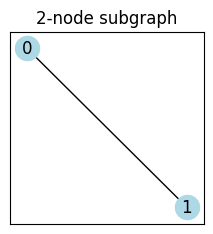

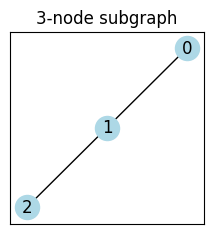

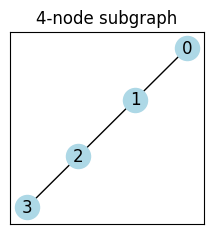

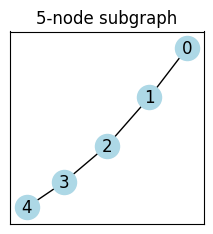

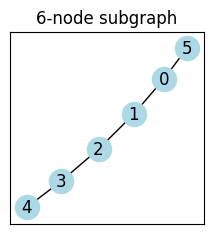

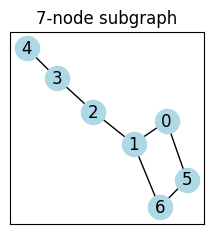

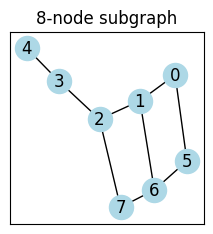

In [22]:
# Visualize one example subgraph for each size
for k in range(2, 9):
    sg = unique_subgraphs[k][0]
    plt.figure(figsize=(2.5, 2.5))
    pos = nx.spring_layout(sg, seed=42)
    nx.draw_networkx(sg, pos, with_labels=True, node_color='lightblue')
    plt.title(f"{k}-node subgraph")
    plt.show()


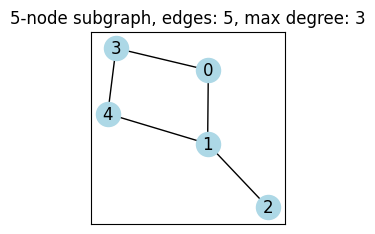

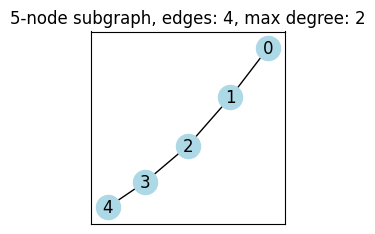

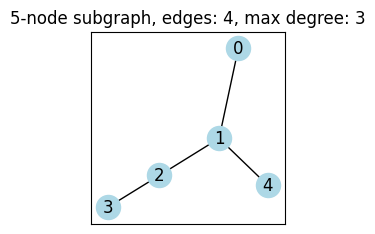

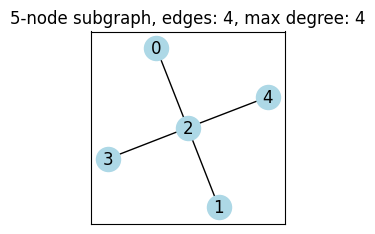

In [ ]:
# Visualize all subgraphs of size 5
k = 5
subgraphs_of_size_k = unique_subgraphs[k]
sorted_by_num_edges_subgraphs_of_size_k = sorted(subgraphs_of_size_k, key=lambda g: g.number_of_edges(), reverse=True)

for sg in sorted_by_num_edges_subgraphs_of_size_k:
    plt.figure(figsize=(2.5, 2.5))
    pos = nx.spring_layout(sg, seed=42)
    nx.draw_networkx(sg, pos, with_labels=True, node_color='lightblue')
    max_degree = max(dict(sg.degree()).values())
    plt.title(f"{k}-node subgraph, edges: {sg.number_of_edges()}, max degree: {max_degree}")
    plt.show()


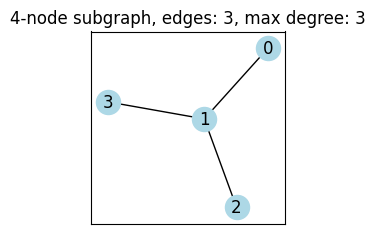

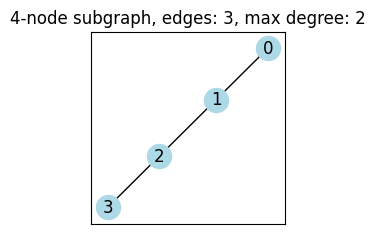

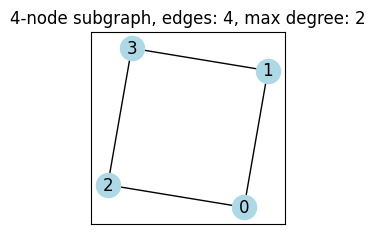

In [23]:
# Visualize all subgraphs of size 5
k = 4
subgraphs_of_size_k = unique_subgraphs[k]
sorted_by_max_degree_subgraphs_of_size_k = sorted_graphs = sorted(
    subgraphs_of_size_k,
    key=lambda g: max(d for _, d in g.degree()),
    reverse=True
)
for sg in sorted_by_max_degree_subgraphs_of_size_k:
    plt.figure(figsize=(2.5, 2.5))
    pos = nx.spring_layout(sg, seed=42)
    nx.draw_networkx(sg, pos, with_labels=True, node_color='lightblue')
    max_degree = max(dict(sg.degree()).values())
    plt.title(f"{k}-node subgraph, edges: {sg.number_of_edges()}, max degree: {max_degree}")
    plt.show()


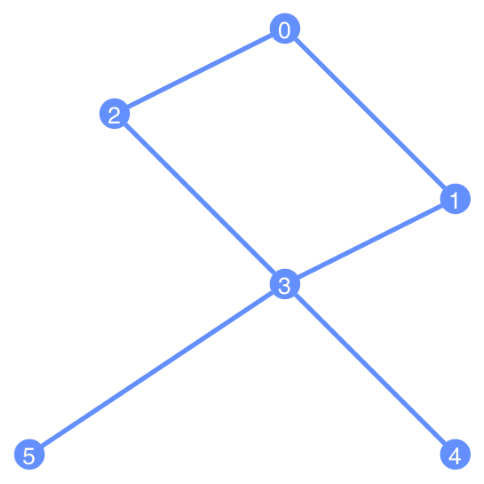

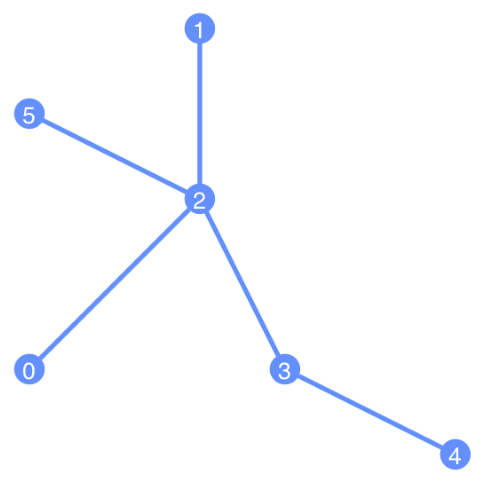

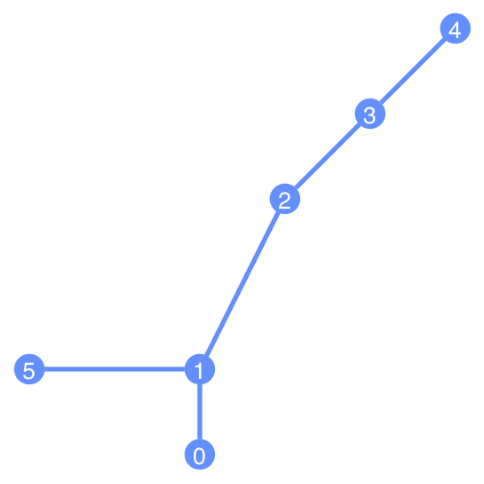

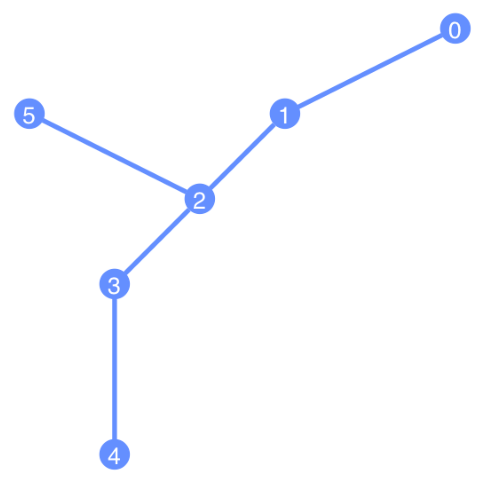

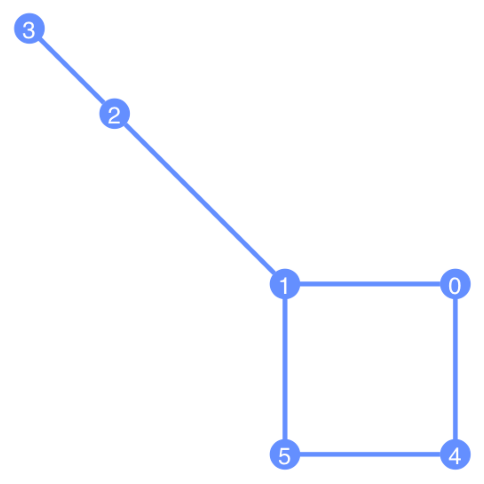

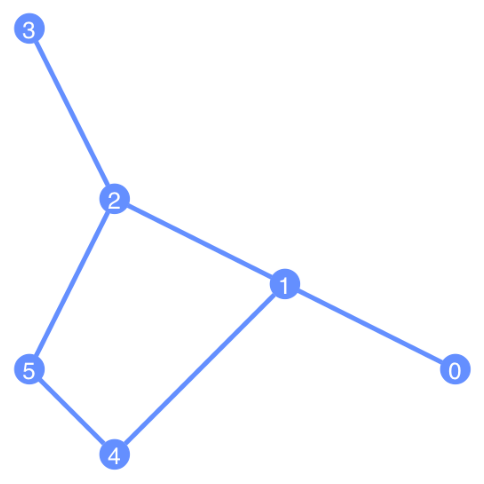

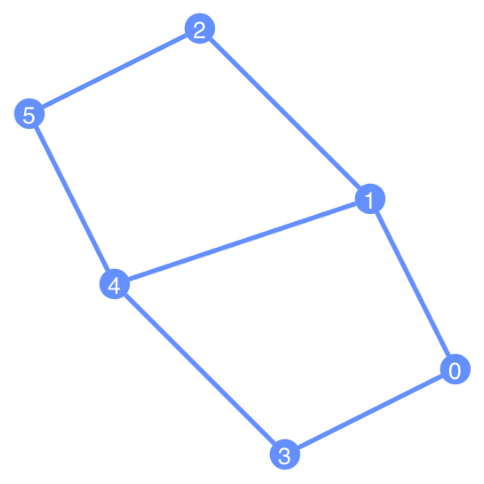

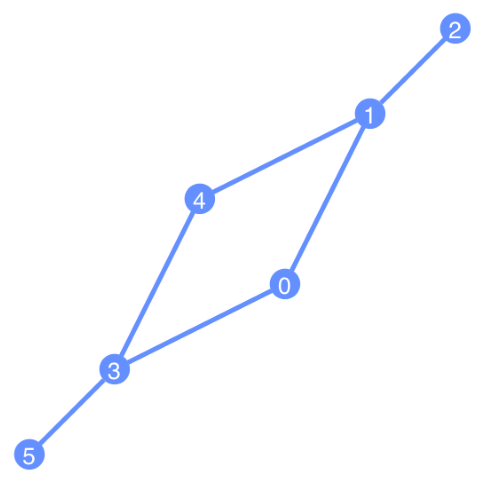

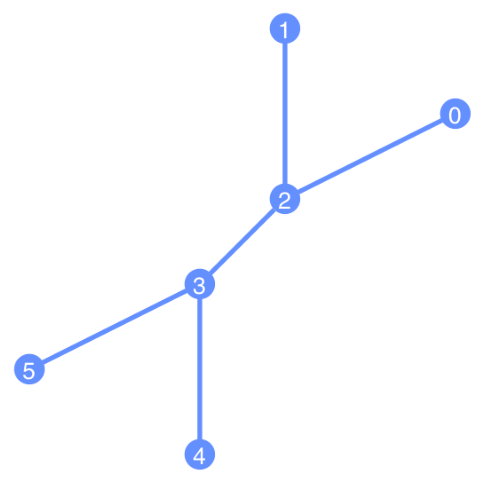

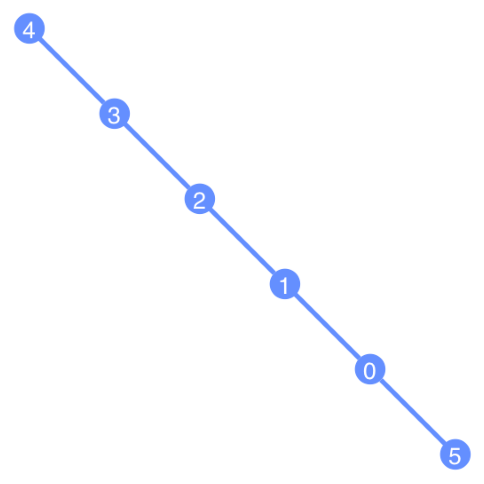

In [37]:
from qiskit.visualization import plot_coupling_map
import networkx as nx
import matplotlib.pyplot as plt

k = 6
subgraphs_of_size_k = unique_subgraphs[k]
sorted_graphs = sorted(
    subgraphs_of_size_k,
    key=lambda g: max(d for _, d in g.degree()),
    reverse=True
)

for sg in sorted_graphs:
    num_qubits = sg.number_of_nodes()
    pos = nx.spring_layout(sg, seed=42)

    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_range = x_max - x_min or 1
    y_range = y_max - y_min or 1

    coords = [
        [round((y_max - pos[q][1]) / y_range * 5), round((pos[q][0] - x_min) / x_range * 5)]
        for q in range(num_qubits)
    ]
    edges = [list(e) for e in sg.edges()]

    max_degree = max(dict(sg.degree()).values())
    fig = plot_coupling_map(
        num_qubits=num_qubits,
        qubit_coordinates=coords,
        coupling_map=edges,
        plot_directed=False,
        label_qubits=True,
    )
    display(fig)


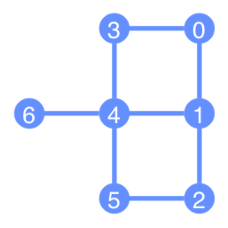

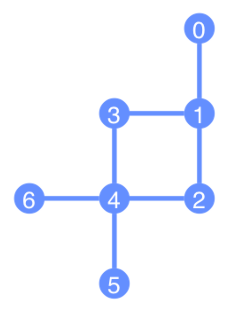

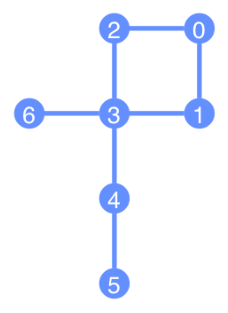

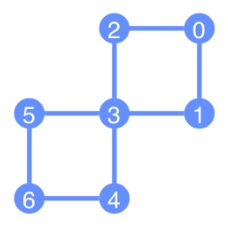

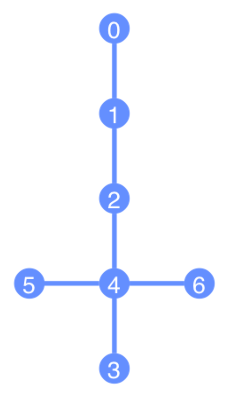

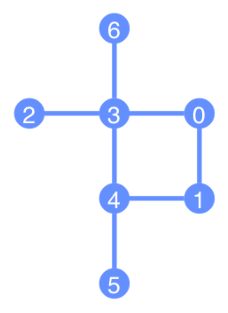

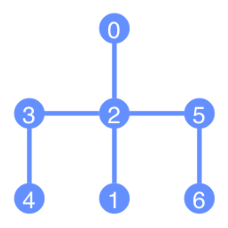

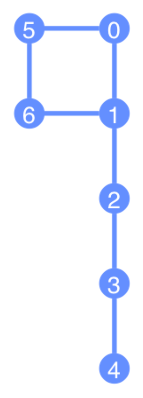

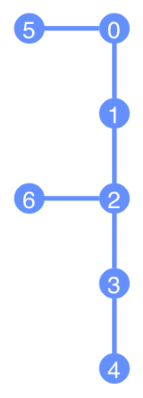

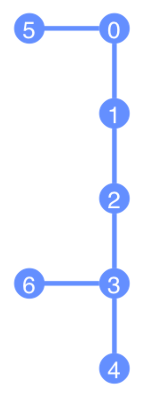

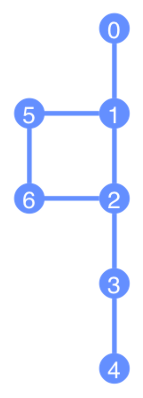

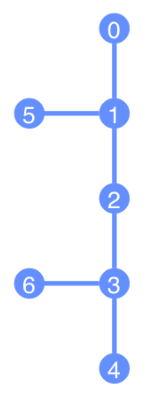

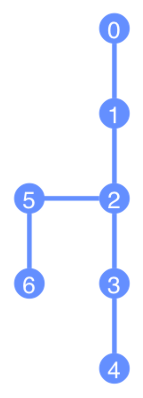

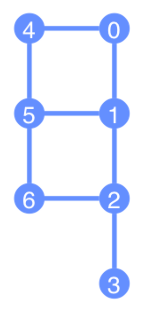

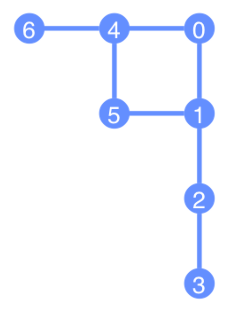

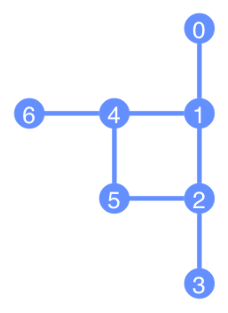

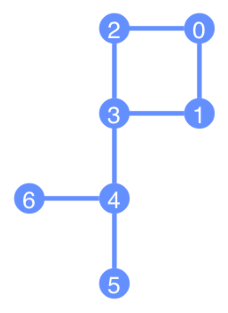

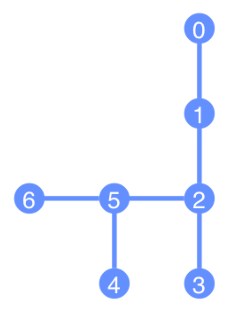

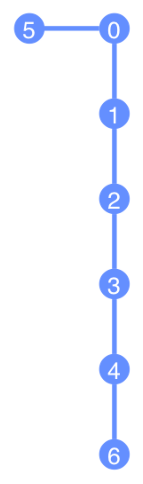

In [33]:
import pickle
from collections import deque
from IPython.display import display
from qiskit.visualization import plot_coupling_map
import networkx as nx

def find_grid_embedding(G):
    root = min(G.nodes())
    bfs_order = [root]
    visited = {root}
    queue = deque([root])
    while queue:
        node = queue.popleft()
        for nb in sorted(G.neighbors(node)):
            if nb not in visited:
                visited.add(nb); bfs_order.append(nb); queue.append(nb)

    pos = {root: (0, 0)}

    def candidates(node):
        placed_nbrs = [n for n in G.neighbors(node) if n in pos]
        occupied = set(pos.values())
        adj_sets = [
            {(pos[pn][0]+dr, pos[pn][1]+dc) for dr,dc in [(0,1),(1,0),(0,-1),(-1,0)]}
            for pn in placed_nbrs
        ]
        return sorted(adj_sets[0].intersection(*adj_sets[1:]) - occupied)

    def backtrack(idx):
        if idx == len(bfs_order): return True
        node = bfs_order[idx]
        for c in candidates(node):
            pos[node] = c
            if backtrack(idx + 1): return True
            del pos[node]
        return False

    backtrack(1)
    min_r = min(r for r,_ in pos.values()); min_c = min(c for _,c in pos.values())
    return {n: (r-min_r, c-min_c) for n,(r,c) in pos.items()}

with open("../unique_subgraphs.pkl", "rb") as f:
    unique_subgraphs = pickle.load(f)

k = 7
sorted_graphs = sorted(unique_subgraphs[k], key=lambda g: max(d for _,d in g.degree()), reverse=True)

for sg in sorted_graphs:
    grid_pos = find_grid_embedding(sg)
    coords = [[grid_pos[q][0], grid_pos[q][1]] for q in range(sg.number_of_nodes())]
    edges = [list(e) for e in sg.edges()]
    max_degree = max(dict(sg.degree()).values())
    fig = plot_coupling_map(
        num_qubits=sg.number_of_nodes(),
        qubit_coordinates=coords,
        coupling_map=edges,
        plot_directed=False,
        label_qubits=True,
    )
    display(fig)


## ✅ Summary

You have now:

- Constructed a 5×5 square lattice
- Enumerated all **connected induced subgraphs** with 2–8 nodes
- Removed duplicates using **graph isomorphism**
- Visualized representative subgraph motifs

These motifs fully represent all possible local subgraphs that can appear in a much larger square lattice.


In [33]:
for k, subgraph_list in unique_subgraphs.items():
    for sg in subgraph_list:
        print(sg)

Graph with 2 nodes and 1 edges
Graph with 3 nodes and 2 edges
Graph with 4 nodes and 3 edges
Graph with 4 nodes and 3 edges
Graph with 4 nodes and 4 edges
Graph with 5 nodes and 4 edges
Graph with 5 nodes and 4 edges
Graph with 5 nodes and 5 edges
Graph with 5 nodes and 4 edges
Graph with 6 nodes and 5 edges
Graph with 6 nodes and 5 edges
Graph with 6 nodes and 5 edges
Graph with 6 nodes and 6 edges
Graph with 6 nodes and 6 edges
Graph with 6 nodes and 7 edges
Graph with 6 nodes and 6 edges
Graph with 6 nodes and 6 edges
Graph with 6 nodes and 5 edges
Graph with 6 nodes and 5 edges
Graph with 7 nodes and 7 edges
Graph with 7 nodes and 6 edges
Graph with 7 nodes and 6 edges
Graph with 7 nodes and 6 edges
Graph with 7 nodes and 7 edges
Graph with 7 nodes and 6 edges
Graph with 7 nodes and 6 edges
Graph with 7 nodes and 8 edges
Graph with 7 nodes and 7 edges
Graph with 7 nodes and 7 edges
Graph with 7 nodes and 8 edges
Graph with 7 nodes and 7 edges
Graph with 7 nodes and 7 edges
Graph wi

In [43]:
import pickle
import json
import networkx as nx
from networkx.algorithms.isomorphism import is_isomorphic
from twisterl.utils import pull_hub_algorithm

# Load unique square lattice subgraphs
with open("unique_subgraphs.pkl", "rb") as f:
    unique_subgraphs = pickle.load(f)

# Download heavy hex models
local_path = pull_hub_algorithm(
    repo_id="Qiskit/ai-transpiler_linear-functions",
    model_path="./models",
    revision="main",
    validate=False
)

# Build a NetworkX graph for each heavy hex model from its JSON gateset
heavy_hex_models = [
    "linear_function_2qL", "linear_function_3qL",
    "linear_function_4qL", "linear_function_4qY",
    "linear_function_5qL", "linear_function_5qT",
    "linear_function_6qL", "linear_function_6qT", "linear_function_6qY",
    "linear_function_7qF", "linear_function_7qH", "linear_function_7qL", "linear_function_7qT", "linear_function_7qY",
    "linear_function_8qF", "linear_function_8qJ", "linear_function_8qL", "linear_function_8qT1", "linear_function_8qT2", "linear_function_8qY",
    "linear_function_9qF1", "linear_function_9qF2", "linear_function_9qH1", "linear_function_9qH2", "linear_function_9qH3",
    "linear_function_9qJ", "linear_function_9qL", "linear_function_9qT1", "linear_function_9qT2", "linear_function_9qY",
    "linear_function_10qL",
]

heavy_hex_graphs = {}
for model_name in heavy_hex_models:
    with open(f"{local_path}/{model_name}.json") as f:
        config = json.load(f)
    edges = {tuple(sorted(qubits)) for _, qubits in config["env"]["gateset"]}
    G = nx.Graph()
    G.add_edges_from(edges)
    heavy_hex_graphs[model_name] = G

# Check which square lattice subgraphs are NOT covered
missing = {}
for k, subgraph_list in unique_subgraphs.items():
    for i, sg in enumerate(subgraph_list):
        if not any(is_isomorphic(sg, hg) for hg in heavy_hex_graphs.values()):
            missing.setdefault(k, []).append((i, sg))

# Report
total_missing = sum(len(v) for v in missing.values())
print(f"Total missing: {total_missing}")
for k, sgs in sorted(missing.items()):
    print(f"\n{k}-node subgraphs missing ({len(sgs)}):")
    for i, sg in sgs:
        print(f"  index {i}, edges: {list(sg.edges())}")


Fetching 63 files:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-19 21:29:57.148 | INFO     | twisterl.utils:pull_hub_algorithm:124 - Model files are now in: ./models/models--Qiskit--ai-transpiler_linear-functions/snapshots/2156b3488c5add527aaf553c8c480c9c020e3d75


Total missing: 69

4-node subgraphs missing (1):
  index 2, edges: [(0, 2), (0, 1), (1, 3), (2, 3)]

5-node subgraphs missing (2):
  index 2, edges: [(0, 3), (0, 1), (1, 4), (1, 2), (3, 4)]
  index 3, edges: [(0, 2), (1, 2), (2, 4), (2, 3)]

6-node subgraphs missing (7):
  index 3, edges: [(0, 4), (0, 1), (1, 5), (1, 2), (2, 3), (4, 5)]
  index 4, edges: [(0, 1), (1, 4), (1, 2), (2, 5), (2, 3), (4, 5)]
  index 5, edges: [(0, 3), (0, 1), (1, 4), (1, 2), (2, 5), (3, 4), (4, 5)]
  index 6, edges: [(0, 3), (0, 1), (1, 4), (1, 2), (3, 5), (3, 4)]
  index 7, edges: [(0, 2), (0, 1), (1, 3), (2, 3), (3, 5), (3, 4)]
  index 8, edges: [(0, 2), (1, 2), (2, 5), (2, 3), (3, 4)]
  index 9, edges: [(0, 2), (1, 2), (2, 3), (3, 5), (3, 4)]

7-node subgraphs missing (14):
  index 0, edges: [(0, 5), (0, 1), (1, 6), (1, 2), (2, 3), (3, 4), (5, 6)]
  index 4, edges: [(0, 1), (1, 5), (1, 2), (2, 6), (2, 3), (3, 4), (5, 6)]
  index 7, edges: [(0, 4), (0, 1), (1, 5), (1, 2), (2, 6), (2, 3), (4, 5), (5, 6)]
  

In [8]:
# Check which square lattice subgraphs ARE covered by heavy hex graphs
covered = {}
for k, subgraph_list in unique_subgraphs.items():
    for i, sg in enumerate(subgraph_list):
        matched_models = [
            name for name, hg in heavy_hex_graphs.items()
            if is_isomorphic(sg, hg)
        ]
        if matched_models:
            covered.setdefault(k, []).append((i, sg, matched_models))

# Report
total_covered = sum(len(v) for v in covered.values())
print(f"Total covered: {total_covered}")
for k, sgs in sorted(covered.items()):
    print(f"\n{k}-node subgraphs covered ({len(sgs)}):")
    for i, sg, models in sgs:
        print(f"  index {i}, edges: {list(sg.edges())}")
        print(f"    matched: {models}")


Total covered: 20

2-node subgraphs covered (1):
  index 0, edges: [(0, 1)]
    matched: ['linear_function_2qL']

3-node subgraphs covered (1):
  index 0, edges: [(0, 1), (1, 2)]
    matched: ['linear_function_3qL']

4-node subgraphs covered (2):
  index 0, edges: [(0, 1), (1, 2), (2, 3)]
    matched: ['linear_function_4qL']
  index 1, edges: [(0, 1), (1, 6), (1, 2)]
    matched: ['linear_function_4qY']

5-node subgraphs covered (2):
  index 0, edges: [(0, 1), (1, 2), (2, 3), (3, 4)]
    matched: ['linear_function_5qL']
  index 1, edges: [(0, 1), (1, 6), (1, 2), (2, 3)]
    matched: ['linear_function_5qT']

6-node subgraphs covered (3):
  index 0, edges: [(0, 5), (0, 1), (1, 2), (2, 3), (3, 4)]
    matched: ['linear_function_6qL']
  index 1, edges: [(0, 1), (1, 6), (1, 2), (2, 3), (3, 4)]
    matched: ['linear_function_6qT']
  index 2, edges: [(0, 1), (1, 2), (2, 7), (2, 3), (3, 4)]
    matched: ['linear_function_6qY']

7-node subgraphs covered (5):
  index 1, edges: [(0, 5), (0, 1), (

In [37]:
degree4_subgraphs = {
    k: [sg for sg in sgs if max(d for _, d in sg.degree()) >= 4]
    for k, sgs in unique_subgraphs.items()
}

for k, sgs in sorted(degree4_subgraphs.items()):
    print(f"{k}-node subgraphs with max degree >= 4: {len(sgs)}")

2-node subgraphs with max degree >= 4: 0
3-node subgraphs with max degree >= 4: 0
4-node subgraphs with max degree >= 4: 0
5-node subgraphs with max degree >= 4: 1
6-node subgraphs with max degree >= 4: 2
7-node subgraphs with max degree >= 4: 7
8-node subgraphs with max degree >= 4: 21


In [ ]:
# Check degree-4 subgraphs that are NOT the pure plus (5-node star)
def is_pure_plus(sg):
    degrees = sorted(d for _, d in sg.degree())
    return sg.number_of_nodes() == 5 and degrees == [1, 1, 1, 1, 4]

for k, sgs in sorted(degree4_subgraphs.items()):
    for i, sg in enumerate(sgs):
        if not is_pure_plus(sg):
            degrees = sorted(d for _, d in sg.degree())
            print(f"  {k}-node, index {i}: degrees={degrees}, edges={list(sg.edges())}")


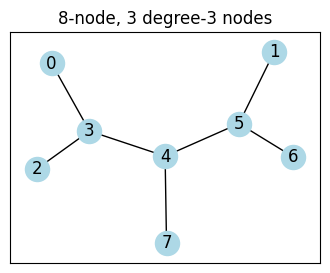

In [40]:
sg = unique_subgraphs[8][45]
plt.figure(figsize=(4, 3))
pos = nx.spring_layout(sg, seed=42)
nx.draw_networkx(sg, pos, with_labels=True, node_color="lightblue")
plt.title("8-node, 3 degree-3 nodes")
plt.show()
